# Laboratorio: Estimación de Canal y Detección en OFDM mediante Deep Learning

**Curso IE-0629 Sistemas de Comunicación — Universidad de Costa Rica**

En este laboratorio compararás receptores OFDM **clásicos** (LS, MMSE, ZF) con receptores basados en **redes neuronales** (CNN para estimar el canal y una DNN que detecta los bits de extremo a extremo).

## Contenido

| Sección | Tema | Herramientas |
|---|---|---|
| 1 | Cadena OFDM clásica: TX, canal multitrayecto, RX, estimación LS/MMSE | NumPy, SciPy |
| 2 | Estimación de canal con una CNN ligera (estilo ReEsNet) tratando el canal como imagen | PyTorch |
| 3 | Receptor DNN *end-to-end* y resiliencia ante CP insuficiente / saturación del HPA | PyTorch |

## Requisitos

* Python 3.9+ con `numpy`, `scipy`, `matplotlib`, `torch` y `tqdm` (en Google Colab ya vienen instalados).
* **No** se necesita ningún conjunto de datos externo: todos los datos se simulan "al vuelo".
* Tiempo de ejecución aproximado en CPU: 5–10 minutos en total (la Sección 3 entrena 3 redes pequeñas). En GPU es más rápido.

> **Sugerencia didáctica:** las celdas de configuración exponen parámetros (`N`, `cp`, modulación, SNR, número de épocas...). Cámbialos y observa qué ocurre.

In [1]:
# ===================== Importaciones y configuración general =====================
import numpy as np                          # álgebra numérica y FFT
import matplotlib.pyplot as plt             # gráficas
from dataclasses import dataclass, replace  # para agrupar los parámetros del sistema
from functools import partial               # para fijar argumentos de funciones
from scipy.interpolate import interp1d      # interpolación lineal / spline (Sección 1)

import torch                                # PyTorch (Secciones 2 y 3)
import torch.nn as nn
from tqdm.auto import tqdm                  # barras de progreso

SEMILLA = 2024
np.random.seed(SEMILLA)                     # reproducibilidad en NumPy
torch.manual_seed(SEMILLA)                  # reproducibilidad en PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # usa GPU si existe

# Estilo homogéneo para todas las figuras
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9,
})
print(f"NumPy {np.__version__} | PyTorch {torch.__version__} | dispositivo: {device}")

NumPy 2.1.3 | PyTorch 2.11.0+cu128 | dispositivo: cuda


---
# Sección 1 — Simulación de la cadena OFDM clásica

## 1.1 Modelo de señal

**Canal multitrayecto** (respuesta al impulso discreta con $L$ tapices o *taps*):

$$
y[n] = \sum_{l=0}^{L-1} h_l \, x[n-l] + w[n], \qquad w[n]\sim\mathcal{CN}(0,\sigma^2)
$$

**Transmisor OFDM.** Los símbolos $X[k]$ ($k=0,\dots,N-1$) se pasan al dominio del tiempo con una IFFT y se antepone un prefijo cíclico (CP) de $N_{cp}$ muestras:

$$
x[n] = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} X[k]\, e^{j 2\pi kn/N}, \qquad n=-N_{cp},\dots,N-1
$$

**Receptor.** Si $N_{cp} \ge L-1$, el CP convierte la convolución lineal en **circular**; tras quitar el CP y aplicar la FFT cada subportadora ve un canal escalar:

$$
\boxed{\,Y[k] = H[k]\,X[k] + N[k]\,}, \qquad H[k]=\sum_{l=0}^{L-1} h_l\, e^{-j2\pi kl/N}
$$

En una rejilla tiempo-frecuencia, $Y[m,k]=H[m,k]X[m,k]+N[m,k]$ con $m$ el índice del símbolo OFDM. Usamos la FFT *ortonormal* ($1/\sqrt{N}$), por lo que $\mathrm{SNR}=E_s/\sigma^2$ por subportadora.

## 1.2 Estimación de canal con pilotos tipo peine

Se transmiten pilotos conocidos $X_p$ cada 4 subportadoras (en todos los símbolos OFDM).

* **Least-Squares (LS)** en las posiciones piloto:
$$
\hat H_{LS}[k_p] = \frac{Y[k_p]}{X[k_p]} = H[k_p] + \frac{N[k_p]}{X[k_p]}
$$
* **Interpolación** (lineal o spline cúbico) sobre las subportadoras de datos.
* **MMSE analítico simplificado (LMMSE en frecuencia):** conocido el perfil de potencia de retardos (PDP) $p_l$, la correlación en frecuencia es $r(\Delta k)=\sum_l p_l e^{-j2\pi l\Delta k/N}$ y
$$
\hat{\mathbf H}_{MMSE} = \mathbf R_{Hp}\left(\mathbf R_{pp}+\sigma^2\mathbf I\right)^{-1}\hat{\mathbf H}_{LS}
$$
donde $\mathbf R_{Hp}$ correlaciona *todas* las subportadoras con las piloto y $\mathbf R_{pp}$ las piloto entre sí. Es "simplificado" porque usamos solo estadísticos de segundo orden (PDP promedio), no el canal instantáneo.

## 1.3 Detección

Ecualización *Zero-Forcing* (ZF) y decisión dura:
$$
\hat X[k] = \frac{Y[k]}{\hat H[k]}
$$

> **Nota de diseño.** Con pilotos cada $\Delta_p=4$ subportadoras el canal se muestrea en frecuencia con $N/\Delta_p=16$ puntos. Por el teorema del muestreo, se puede reconstruir sin aliasing si la dispersión de retardos es menor que $N/\Delta_p=16$ muestras. Aquí el retardo máximo es 12, así que el muestreo es suficiente, pero la interpolación sigue introduciendo error (y el spline puede amplificar el ruido de los pilotos): ¡compruébalo en las gráficas!

In [2]:
# ---------------- 1.4 Parámetros del sistema y utilidades de modulación ----------------
@dataclass
class Cfg:
    """Agrupa todos los parámetros de un sistema OFDM."""
    N: int = 64              # número de subportadoras
    cp: int = 16             # longitud del prefijo cíclico (muestras)
    n_sym: int = 14          # símbolos OFDM por trama (eje del tiempo)
    mod: str = "QPSK"        # "QPSK" o "16QAM"
    n_taps: int = 5          # número de tapices (trayectos) del canal
    max_delay: int = 12      # retardo máximo de un trayecto (muestras)
    tau: float = 4.0         # constante de decaimiento exponencial del PDP
    fd: float = 0.02         # Doppler normalizado (f_d * T_simbolo) -> canal variante en el tiempo
    pilot_mask: np.ndarray = None   # máscara booleana [n_sym, N]: True donde hay piloto
    pilot_vals: np.ndarray = None   # valores piloto QPSK conocidos [n_sym, N]

    def __post_init__(self):
        if self.pilot_vals is None:                       # pilotos QPSK pseudoaleatorios pero fijos (conocidos por el RX)
            r = np.random.default_rng(1234)
            b = r.integers(0, 2, (self.n_sym, self.N, 2))
            self.pilot_vals = ((1 - 2 * b[..., 0]) + 1j * (1 - 2 * b[..., 1])) / np.sqrt(2)

    @property
    def bps(self):    return 2 if self.mod == "QPSK" else 4          # bits por símbolo
    @property
    def D(self):      return self.max_delay + 1                      # longitud de la respuesta al impulso densa
    @property
    def n_data(self): return int((~self.pilot_mask).sum())           # celdas de datos por trama


MODULACION = "QPSK"          # <- cambia a "16QAM" para experimentar (necesitará más SNR)
SEP_PILOTO = 4               # pilotos cada 4 subportadoras (tipo peine)

cfg1 = Cfg(N=64, cp=16, n_sym=14, mod=MODULACION)
cfg1.pilot_mask = np.zeros((cfg1.n_sym, cfg1.N), dtype=bool)
cfg1.pilot_mask[:, ::SEP_PILOTO] = True                  # pilotos en las subportadoras 0,4,8,...,60 de cada símbolo

def idx_pilotos(cfg):
    """Índices de subportadora que contienen pilotos (deben ser iguales en todos los símbolos)."""
    return np.where(cfg.pilot_mask[0])[0]

pidx = idx_pilotos(cfg1)
print(f"Subportadoras: {cfg1.N} | CP: {cfg1.cp} | Pilotos por símbolo: {len(pidx)} | Datos por trama: {cfg1.n_data} celdas")


def mapear(bits, mod):
    """Bits [..., bps] -> símbolos complejos con potencia media unitaria (mapeo Gray)."""
    if mod == "QPSK":
        return ((1 - 2 * bits[..., 0]) + 1j * (1 - 2 * bits[..., 1])) / np.sqrt(2)
    eje = lambda a, b: (1 - 2 * a) * (2 - (1 - 2 * b))    # 16-QAM Gray por eje: niveles {-3,-1,+1,+3}
    return (eje(bits[..., 0], bits[..., 1]) + 1j * eje(bits[..., 2], bits[..., 3])) / np.sqrt(10)

def demapear(s, mod):
    """Decisión dura: símbolos ecualizados -> bits [..., bps]."""
    if mod == "QPSK":
        return np.stack([s.real < 0, s.imag < 0], axis=-1).astype(int)
    vr, vi = s.real * np.sqrt(10), s.imag * np.sqrt(10)   # devuelve a los niveles {-3,-1,1,3}
    return np.stack([vr < 0, np.abs(vr) > 2, vi < 0, np.abs(vi) > 2], axis=-1).astype(int)

# Verificación rápida: mapear -> demapear debe ser la identidad
_b = np.random.randint(0, 2, (1000, cfg1.bps))
assert np.array_equal(demapear(mapear(_b, cfg1.mod), cfg1.mod), _b), "Error en el mapeo/demapeo"
print("Mapeo/demapeo verificado. Potencia media de la constelación:", np.mean(np.abs(mapear(_b, cfg1.mod))**2).round(3))

Subportadoras: 64 | CP: 16 | Pilotos por símbolo: 16 | Datos por trama: 672 celdas
Mapeo/demapeo verificado. Potencia media de la constelación: 1.0


In [3]:
# ---------------- 1.5 Modelo de canal multitrayecto (con desvanecimiento Rayleigh) ----------------
def generar_taps(cfg, B, rng):
    """Genera B realizaciones del canal en el tiempo.
    Devuelve taps [B, n_sym, D]: coeficientes h_l de cada símbolo OFDM (D = max_delay+1, ceros donde no hay trayecto)."""
    # Retardos aleatorios: el primer trayecto siempre en 0; los demás son enteros distintos en 1..max_delay
    aleatorio = rng.random((B, cfg.max_delay))
    retardos = np.concatenate([np.zeros((B, 1), int),
                               np.argsort(aleatorio, axis=1)[:, :cfg.n_taps - 1] + 1], axis=1)   # [B, n_taps]
    pot = np.exp(-retardos / cfg.tau)                       # perfil de potencia exponencial decreciente
    pot /= pot.sum(axis=1, keepdims=True)                   # normalizado: potencia total del canal = 1
    # Amplitudes complejas gaussianas (Rayleigh) con varianza pot/2 por componente
    amp = np.sqrt(pot / 2) * (rng.standard_normal((B, cfg.n_taps)) + 1j * rng.standard_normal((B, cfg.n_taps)))
    # Efecto Doppler: cada trayecto rota su fase de un símbolo OFDM al siguiente con su propia frecuencia
    fd = cfg.fd * np.cos(2 * np.pi * rng.random((B, cfg.n_taps)))        # Doppler de cada trayecto (tipo Jakes)
    k = np.arange(cfg.n_sym)[None, :, None]                              # índice de símbolo OFDM
    valores = amp[:, None, :] * np.exp(1j * 2 * np.pi * fd[:, None, :] * k)   # [B, n_sym, n_taps]
    taps = np.zeros((B, cfg.n_sym, cfg.D), dtype=complex)
    for i in range(cfg.n_taps):                                          # coloca cada trayecto en su retardo
        taps[np.arange(B), :, retardos[:, i]] = valores[:, :, i]
    return taps

def respuesta_frecuencia(taps, N):
    """H[m,k] = sum_l h_l[m] exp(-j 2 pi k l / N)  ->  canal 'verdadero' en la rejilla tiempo-frecuencia [B, n_sym, N]."""
    l = np.arange(taps.shape[-1])[:, None]
    k = np.arange(N)[None, :]
    return taps @ np.exp(-2j * np.pi * l * k / N)            # (B,T,D) @ (D,N) -> (B,T,N)

def aplicar_canal(tx, taps, largo_sim):
    """Convolución lineal de la señal serie con taps que cambian de un símbolo OFDM a otro.
    Al trabajar sobre el flujo completo, si el CP es corto aparece ISI entre símbolos consecutivos."""
    B, Ls = tx.shape
    y = np.zeros_like(tx, dtype=complex)
    for l in range(taps.shape[-1]):
        if not np.any(taps[:, :, l]):                        # salta retardos sin trayecto
            continue
        g = np.repeat(taps[:, :, l], largo_sim, axis=1)      # ganancia del tap l en cada muestra [B, Ls]
        xs = np.zeros_like(tx, dtype=complex)
        xs[:, l:] = tx[:, :Ls - l]                           # x[n-l]: señal retrasada l muestras
        y += g * xs                                          # y[n] += h_l x[n-l]
    return y

In [4]:
# ---------------- 1.6 Cadena completa TX -> canal -> RX (vectorizada sobre B tramas) ----------------
def simular(cfg, B, snr_db, rng, cp=None, clip_ratio=None):
    """Simula B tramas OFDM completas.
    snr_db     : escalar o arreglo [B] con la SNR (Es/N0) por trama.
    cp         : permite sobreescribir el CP de cfg (para el experimento de CP insuficiente).
    clip_ratio : si no es None, satura la señal en el TX a clip_ratio * RMS (modelo simple de HPA).
    Devuelve dict con X (TX), Y (RX en frecuencia), H (canal verdadero), bits, taps."""
    cp = cfg.cp if cp is None else cp
    N, T = cfg.N, cfg.n_sym
    snr_db = np.broadcast_to(np.asarray(snr_db, dtype=float), (B,))

    # --- Transmisor: bits -> símbolos -> rejilla tiempo-frecuencia ---
    bits = rng.integers(0, 2, (B, cfg.n_data, cfg.bps))                 # bits de datos aleatorios
    X = np.zeros((B, T, N), dtype=complex)
    X[:, cfg.pilot_mask] = cfg.pilot_vals[cfg.pilot_mask]              # coloca los pilotos conocidos
    X[:, ~cfg.pilot_mask] = mapear(bits, cfg.mod)                      # coloca los símbolos de datos
    x = np.fft.ifft(X, axis=-1, norm="ortho")                          # IFFT: frecuencia -> tiempo
    if cp > 0:
        x = np.concatenate([x[..., -cp:], x], axis=-1)                 # prefijo cíclico: copia las últimas cp muestras al inicio
    tx = x.reshape(B, -1)                                              # serializa los símbolos OFDM

    # --- (Opcional) no linealidad del amplificador: recorte ("clipping") ---
    if clip_ratio is not None:
        A = clip_ratio * np.sqrt(np.mean(np.abs(tx) ** 2, axis=1, keepdims=True))   # umbral de saturación
        mag = np.abs(tx)
        tx = np.where(mag > A, A * tx / np.maximum(mag, 1e-12), tx)                 # recorta la magnitud, conserva la fase

    # --- Canal: multitrayecto variante + AWGN ---
    taps = generar_taps(cfg, B, rng)
    rx = aplicar_canal(tx, taps, N + cp)
    sigma = 10 ** (-snr_db / 20)                                       # desviación estándar del ruido (potencia de señal = 1)
    rx = rx + sigma[:, None] / np.sqrt(2) * (rng.standard_normal(rx.shape) + 1j * rng.standard_normal(rx.shape))

    # --- Receptor: quitar CP -> FFT ---
    rx = rx.reshape(B, T, N + cp)[..., cp:]                            # elimina el prefijo cíclico
    Y = np.fft.fft(rx, axis=-1, norm="ortho")                          # FFT: tiempo -> frecuencia
    H = respuesta_frecuencia(taps, N)                                  # canal verdadero (referencia)
    return {"X": X, "Y": Y, "H": H, "bits": bits, "taps": taps, "snr": snr_db}

# Verificación: con CP suficiente y ruido despreciable, debe cumplirse Y = H * X
_s = simular(cfg1, 5, 100.0, np.random.default_rng(0))
print("max |Y - H·X| con SNR=100 dB (debe ser ~1e-5):", np.max(np.abs(_s["Y"] - _s["H"] * _s["X"])))

max |Y - H·X| con SNR=100 dB (debe ser ~1e-5): 2.8974075734617075e-05


In [5]:
# ---------------- 1.7 Estimadores de canal clásicos ----------------
def interp_frec(Hp, pidx, N, tipo="linear"):
    """Interpola en frecuencia la estimación en pilotos Hp [..., n_pilotos] a las N subportadoras.
    Se interpolan por separado parte real e imaginaria; 'extrapolate' cubre los bordes sin piloto."""
    f = np.arange(N)
    re = interp1d(pidx, Hp.real, kind=tipo, axis=-1, fill_value="extrapolate")(f)
    im = interp1d(pidx, Hp.imag, kind=tipo, axis=-1, fill_value="extrapolate")(f)
    return re + 1j * im

def ls_en_pilotos(cfg, sim):
    """Estimador LS en las posiciones piloto: H_LS = Y / X_piloto."""
    pidx = idx_pilotos(cfg)
    return sim["Y"][..., pidx] / cfg.pilot_vals[:, pidx]              # [B, n_sym, n_pilotos]

def est_perfecto(cfg, sim, snr_db):
    return sim["H"]                                                    # referencia: canal conocido

def est_ls_interp(cfg, sim, snr_db, tipo="linear"):
    Hp = ls_en_pilotos(cfg, sim)                                       # LS en pilotos
    return interp_frec(Hp, idx_pilotos(cfg), cfg.N, tipo)              # interpolación a toda la rejilla

def pdp_medio(cfg, n=4000, seed=0):
    """PDP promedio E|h_l|^2, estimado por Monte Carlo con el propio generador de canales.
    Es la 'estadística de segundo orden' que asume el estimador MMSE."""
    t = generar_taps(cfg, n, np.random.default_rng(seed))
    return np.mean(np.abs(t) ** 2, axis=(0, 1))                       # [D]

def est_mmse(cfg, sim, snr_db, pdp=None):
    """LMMSE en frecuencia: H_mmse = R_Hp (R_pp + sigma^2 I)^-1 H_LS."""
    pidx = idx_pilotos(cfg); N = cfg.N
    l = np.arange(cfg.D)
    r = lambda d: (pdp * np.exp(-2j * np.pi * d[..., None] * l / N)).sum(-1)   # r(dk) = sum_l p_l e^{-j2pi l dk/N}
    f = np.arange(N)
    R_fp = r(f[:, None] - pidx[None, :])                               # correlación (todas las subportadoras) x (pilotos)
    R_pp = r(pidx[:, None] - pidx[None, :])                            # correlación pilotos x pilotos
    sigma2 = 10 ** (-snr_db / 10)                                      # varianza del ruido en cada piloto (|X_p| = 1)
    W = R_fp @ np.linalg.inv(R_pp + sigma2 * np.eye(len(pidx)))        # filtro de Wiener [N, n_pilotos]
    return np.einsum("btp,fp->btf", ls_en_pilotos(cfg, sim), W)        # aplica el filtro a cada símbolo OFDM

# ---------------- 1.8 Detector y curvas de BER ----------------
def ber_detector(cfg, sim, Hhat):
    """Ecualiza con ZF (X_hat = Y / H_hat), decide y cuenta errores de bit en las celdas de datos."""
    Xh = sim["Y"] / Hhat
    bits_hat = demapear(Xh[:, ~cfg.pilot_mask], cfg.mod)
    return np.mean(bits_hat != sim["bits"])

def curva_ber(cfg, snrs, estimadores, n_frames=200, seed=1, **kw):
    """BER vs SNR. Todos los estimadores se evalúan sobre las MISMAS tramas (comparación justa)."""
    rng = np.random.default_rng(seed)
    res = {n: [] for n in estimadores}
    for s in tqdm(snrs, desc="BER vs SNR", leave=False):
        sim = simular(cfg, n_frames, s, rng, **kw)
        for n, est in estimadores.items():
            res[n].append(ber_detector(cfg, sim, est(cfg, sim, s)))
    return {n: np.array(v) for n, v in res.items()}

PDP1 = pdp_medio(cfg1)                                                 # PDP promedio para el MMSE
print("PDP promedio (primeros 13 retardos):", np.round(PDP1, 3))

PDP promedio (primeros 13 retardos): [0.5   0.102 0.085 0.076 0.055 0.047 0.035 0.03  0.023 0.019 0.014 0.011
 0.009]


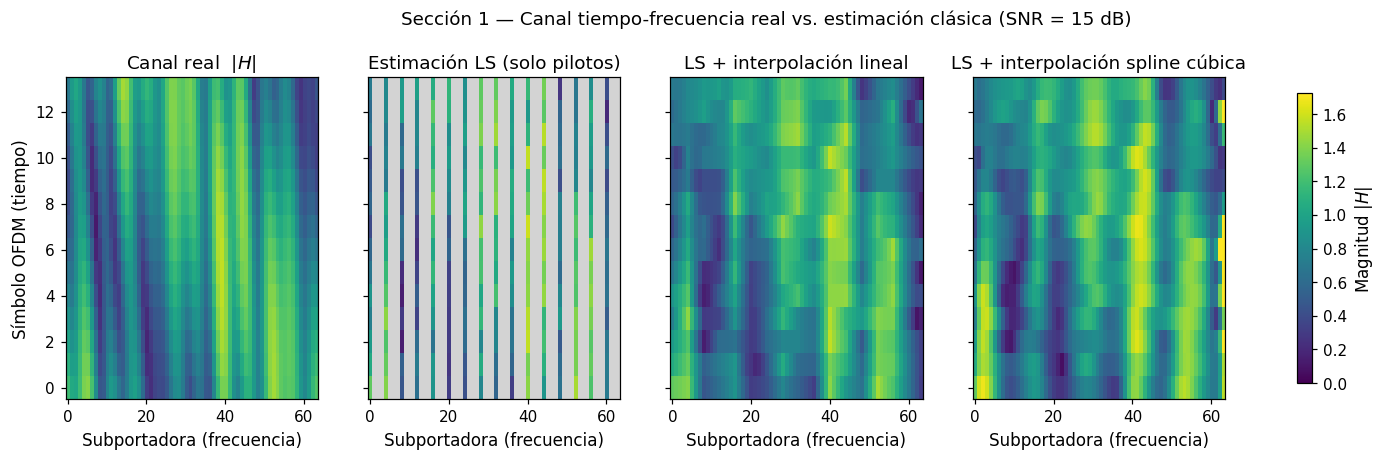

NMSE LS + lineal :  -9.78 dB
NMSE LS + spline :  -6.64 dB


In [6]:
# ---------------- 1.9 Visualización: mapa de calor del canal real vs. LS + interpolación ----------------
rng = np.random.default_rng(7)
sim = simular(cfg1, 1, 15.0, rng)                                      # una trama a SNR = 15 dB

H_real   = sim["H"][0]                                                 # canal verdadero [n_sym, N]
Hp       = ls_en_pilotos(cfg1, sim)[0]                                 # LS solo en pilotos [n_sym, n_pilotos]
H_ls_lin = est_ls_interp(cfg1, sim, 15.0, "linear")[0]                 # LS + interpolación lineal
H_ls_spl = est_ls_interp(cfg1, sim, 15.0, "cubic")[0]                  # LS + spline cúbico

Hp_grid = np.full((cfg1.n_sym, cfg1.N), np.nan)                        # rejilla vacía salvo en pilotos
Hp_grid[:, pidx] = np.abs(Hp)

cmap = plt.get_cmap("viridis").copy(); cmap.set_bad("lightgray")       # celdas sin piloto en gris
vmin, vmax = 0, np.abs(H_real).max() * 1.1
paneles = [(np.abs(H_real), "Canal real  $|H|$"),
           (np.ma.masked_invalid(Hp_grid), "Estimación LS (solo pilotos)"),
           (np.abs(H_ls_lin), "LS + interpolación lineal"),
           (np.abs(H_ls_spl), "LS + interpolación spline cúbica")]

fig, ejes = plt.subplots(1, 4, figsize=(17, 3.8), sharey=True)
for ax, (M, titulo) in zip(ejes, paneles):
    im = ax.imshow(M, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(titulo); ax.set_xlabel("Subportadora (frecuencia)"); ax.grid(False)
ejes[0].set_ylabel("Símbolo OFDM (tiempo)")
fig.colorbar(im, ax=ejes, label="Magnitud $|H|$", shrink=0.9)
fig.suptitle("Sección 1 — Canal tiempo-frecuencia real vs. estimación clásica (SNR = 15 dB)", y=1.04)
plt.show()

for nombre, Hh in [("LS + lineal", H_ls_lin), ("LS + spline", H_ls_spl)]:
    nmse = np.sum(np.abs(Hh - H_real) ** 2) / np.sum(np.abs(H_real) ** 2)
    print(f"NMSE {nombre:12s}: {10*np.log10(nmse):6.2f} dB")

BER vs SNR:   0%|          | 0/7 [00:00<?, ?it/s]

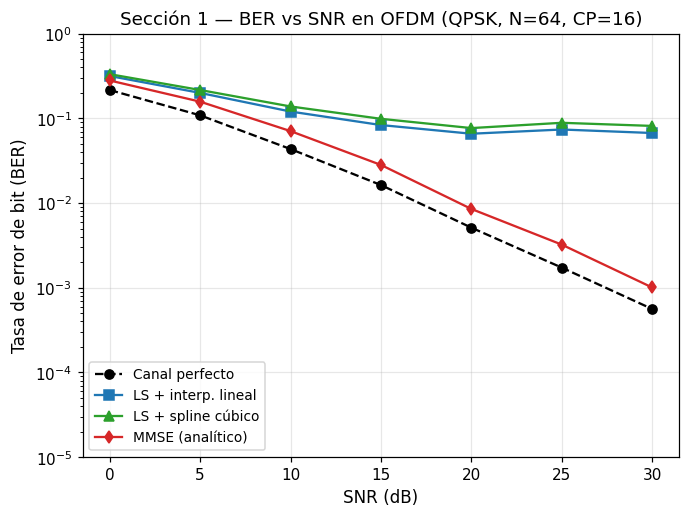

In [7]:
# ---------------- 1.10 BER vs SNR: LS vs MMSE vs canal perfecto ----------------
snrs1 = np.arange(0, 31, 5)                                            # SNR de 0 a 30 dB
estim1 = {
    "Canal perfecto":       est_perfecto,
    "LS + interp. lineal":  partial(est_ls_interp, tipo="linear"),
    "LS + spline cúbico":   partial(est_ls_interp, tipo="cubic"),
    "MMSE (analítico)":     partial(est_mmse, pdp=PDP1),
}
ber1 = curva_ber(cfg1, snrs1, estim1, n_frames=200, seed=11)

estilos = {"Canal perfecto": "k--o", "LS + interp. lineal": "C0-s", "LS + spline cúbico": "C2-^", "MMSE (analítico)": "C3-d"}
plt.figure(figsize=(7, 5))
for n, v in ber1.items():
    plt.semilogy(snrs1, np.maximum(v, 1e-6), estilos[n], label=n)       # piso 1e-6 para poder graficar BER = 0
plt.xlabel("SNR (dB)"); plt.ylabel("Tasa de error de bit (BER)")
plt.title(f"Sección 1 — BER vs SNR en OFDM ({cfg1.mod}, N={cfg1.N}, CP={cfg1.cp})")
plt.ylim(1e-5, 1); plt.legend(); plt.show()

---
# Sección 2 — Estimación de canal basada en Deep Learning (PyTorch)

## 2.1 El canal como una imagen 2D

La rejilla tiempo-frecuencia $H[m,k]$ se parece a una imagen de $T\times N$ píxeles con **2 canales** (parte real e imaginaria). El problema de estimar el canal a partir de pilotos es análogo a la **super-resolución de imágenes**:

$$
\underbrace{\hat H_{LS}[m,k_p]}_{\text{entrada: } [B,\,2,\,T,\,N/4]} \;\xrightarrow{\;f_\theta\;}\; \underbrace{\hat H_{CNN}[m,k]}_{\text{salida: } [B,\,2,\,T,\,N]}
$$

## 2.2 Arquitectura (inspirada en ReEsNet / ChannelNet)

1. Conv $3{\times}3$ + BatchNorm + ReLU (extrae características de la rejilla de pilotos).
2. Bloque residual: dos Conv $3{\times}3$ + BN + ReLU con conexión de salto.
3. **Deconvolución** (`ConvTranspose2d`, factor 4 en frecuencia) que recupera las $N$ subportadoras.
4. **Aprendizaje residual:** la salida es una interpolación lineal *fija* de los pilotos más una corrección que aprende la red, es decir $\hat H = \mathrm{interp}(\hat H_{LS}) + f_\theta(\hat H_{LS})$. Así la red parte de una solución razonable y solo aprende lo que falta.

## 2.3 Entrenamiento sintético "on-the-fly"

En cada iteración se **simulan tramas OFDM nuevas** (canal y ruido aleatorios, SNR uniforme en [0, 20] dB); no hay un dataset finito y por lo tanto no hay sobreajuste al conjunto de entrenamiento. La pérdida es el error cuadrático medio normalizado:

$$
\mathrm{NMSE}=\frac{\sum \lVert \hat H - H\rVert^2}{\sum \lVert H\rVert^2}
$$

In [8]:
# ---------------- 2.4 Generador de datos "on-the-fly" ----------------
n_p = len(pidx)                                                        # número de pilotos por símbolo (16)

def batch_entrenamiento(B, rng, snr_rango=(0.0, 20.0)):
    """Simula B tramas OFDM con SNR aleatoria y devuelve (entrada, objetivo) como tensores de PyTorch.
    entrada : LS en pilotos  [B, 2, T, n_p]   (2 canales = Re, Im)
    objetivo: canal real     [B, 2, T, N]"""
    snr = rng.uniform(*snr_rango, size=B)                              # una SNR distinta para cada trama
    sim = simular(cfg1, B, snr, rng)                                   # cadena OFDM completa (Sección 1)
    Hp = ls_en_pilotos(cfg1, sim)                                      # estimación LS ruidosa en pilotos
    x = np.stack([Hp.real, Hp.imag], axis=1)                           # [B, 2, T, n_p]
    y = np.stack([sim["H"].real, sim["H"].imag], axis=1)               # [B, 2, T, N]
    return (torch.tensor(x, dtype=torch.float32, device=device),
            torch.tensor(y, dtype=torch.float32, device=device))

x_demo, y_demo = batch_entrenamiento(4, np.random.default_rng(0))
print("Forma de la entrada :", tuple(x_demo.shape), " [Lote, 2, Tiempo, Pilotos]")
print("Forma del objetivo  :", tuple(y_demo.shape), " [Lote, 2, Tiempo, Frecuencia]")

Forma de la entrada : (4, 2, 14, 16)  [Lote, 2, Tiempo, Pilotos]
Forma del objetivo  : (4, 2, 14, 64)  [Lote, 2, Tiempo, Frecuencia]


In [9]:
# ---------------- 2.5 Modelo: CNN ligera con aprendizaje residual y deconvolución ----------------
# Matriz de interpolación lineal [N, n_p] (misma que usa el LS + lineal clásico); se guarda como constante de la red
W_lin = interp1d(pidx, np.eye(n_p), kind="linear", axis=0, fill_value="extrapolate")(np.arange(cfg1.N))

class CanalCNN(nn.Module):
    def __init__(self, W_lin, ch=32, factor=SEP_PILOTO):
        super().__init__()
        self.register_buffer("W_lin", torch.tensor(W_lin, dtype=torch.float32))   # constante (no se entrena)
        self.entrada = nn.Sequential(                                  # capa 1: Conv + BN + ReLU
            nn.Conv2d(2, ch, kernel_size=3, padding=1), nn.BatchNorm2d(ch), nn.ReLU())
        self.medio = nn.Sequential(                                    # capas 2 y 3: bloque residual
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU())
        # Capa final: deconvolución que multiplica por 'factor' el eje de frecuencia (n_p -> N), deja el tiempo igual
        self.deconv = nn.ConvTranspose2d(ch, 2, kernel_size=(1, factor), stride=(1, factor))

    def forward(self, x):                                              # x: [B, 2, T, n_p]
        base = torch.einsum("bctp,fp->bctf", x, self.W_lin)            # interpolación lineal fija -> [B, 2, T, N]
        f = self.entrada(x)                                            # características iniciales
        f = f + self.medio(f)                                          # conexión residual
        return base + self.deconv(f)                                   # base + corrección aprendida

modelo_cnn = CanalCNN(W_lin).to(device)
print(modelo_cnn)
print("Parámetros entrenables:", sum(p.numel() for p in modelo_cnn.parameters()))
with torch.no_grad():
    print("Forma de salida:", tuple(modelo_cnn.eval()(x_demo).shape))     # debe ser [4, 2, 14, 64]

CanalCNN(
  (entrada): Sequential(
    (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (medio): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (deconv): ConvTranspose2d(32, 2, kernel_size=(1, 4), stride=(1, 4))
)
Parámetros entrenables: 19554
Forma de salida: (4, 2, 14, 64)


In [10]:
# ---------------- 2.6 Entrenamiento (10-15 épocas, con barra de progreso) ----------------
EPOCAS, PASOS_POR_EPOCA, TAM_LOTE = 15, 60, 64
rng_tr = np.random.default_rng(123)                                    # generador para entrenamiento
x_val, y_val = batch_entrenamiento(512, np.random.default_rng(999))    # conjunto de validación FIJO

def nmse_torch(pred, obj):
    return torch.sum((pred - obj) ** 2) / torch.sum(obj ** 2)          # NMSE de todo el lote

opt = torch.optim.Adam(modelo_cnn.parameters(), lr=2e-3)               # optimizador Adam
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCAS)  # reduce la tasa de aprendizaje suavemente
hist_train, hist_val = [], []

# NMSE del baseline (LS + lineal) en validación = salida de la red con corrección cero
with torch.no_grad():
    nmse_base = nmse_torch(torch.einsum("bctp,fp->bctf", x_val, modelo_cnn.W_lin), y_val).item()

for ep in tqdm(range(EPOCAS), desc="Entrenando CNN"):
    modelo_cnn.train()                                                 # BatchNorm en modo entrenamiento
    acum = 0.0
    for _ in range(PASOS_POR_EPOCA):
        x, y = batch_entrenamiento(TAM_LOTE, rng_tr)                   # ¡datos nuevos en cada paso!
        loss = nmse_torch(modelo_cnn(x), y)                            # pérdida: NMSE(H_pred, H_real)
        opt.zero_grad()                                                # borra gradientes previos
        loss.backward()                                                # retropropagación
        opt.step()                                                     # actualiza pesos
        acum += loss.item()
    sched.step()
    modelo_cnn.eval()                                                  # BatchNorm en modo evaluación
    with torch.no_grad():
        hist_val.append(nmse_torch(modelo_cnn(x_val), y_val).item())   # NMSE de validación
    hist_train.append(acum / PASOS_POR_EPOCA)

print(f"NMSE final (validación): {10*np.log10(hist_val[-1]):.2f} dB  |  baseline LS+lineal: {10*np.log10(nmse_base):.2f} dB")

Entrenando CNN:   0%|          | 0/15 [00:00<?, ?it/s]

NMSE final (validación): -11.72 dB  |  baseline LS+lineal: -5.08 dB


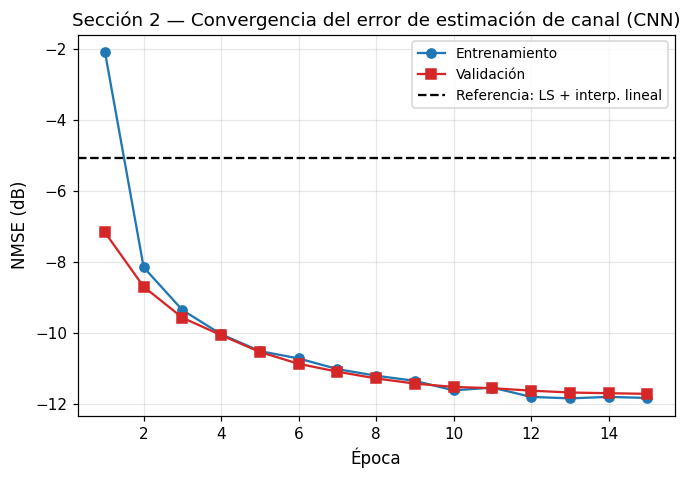

In [11]:
# ---------------- 2.7 Curva de convergencia ----------------
ep = np.arange(1, EPOCAS + 1)
plt.figure(figsize=(7, 4.5))
plt.plot(ep, 10 * np.log10(hist_train), "C0-o", label="Entrenamiento")
plt.plot(ep, 10 * np.log10(hist_val), "C3-s", label="Validación")
plt.axhline(10 * np.log10(nmse_base), color="k", ls="--", label="Referencia: LS + interp. lineal")
plt.xlabel("Época"); plt.ylabel("NMSE (dB)")
plt.title("Sección 2 — Convergencia del error de estimación de canal (CNN)")
plt.legend(); plt.show()

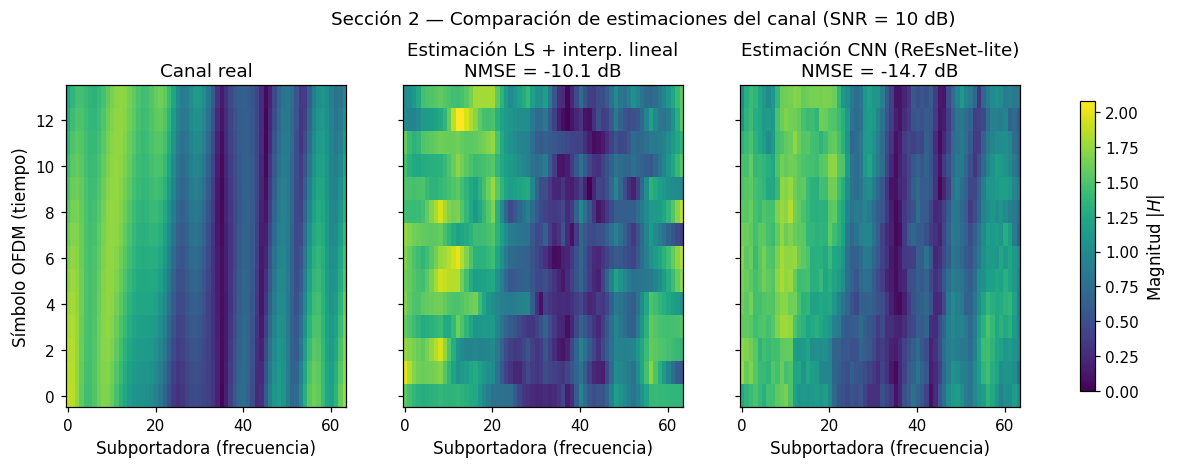

In [12]:
# ---------------- 2.8 Comparación visual: Canal real | LS | CNN ----------------
@torch.no_grad()
def est_cnn(cfg, sim, snr_db):
    """Estimador basado en la CNN: LS en pilotos -> red -> canal completo [B, T, N] complejo."""
    modelo_cnn.eval()
    Hp = ls_en_pilotos(cfg, sim)
    x = torch.tensor(np.stack([Hp.real, Hp.imag], axis=1), dtype=torch.float32, device=device)
    out = modelo_cnn(x).cpu().numpy()
    return out[:, 0] + 1j * out[:, 1]                                  # recompone el complejo

rng = np.random.default_rng(21)
SNR_VIS = 10.0
sim = simular(cfg1, 1, SNR_VIS, rng)
H_real = sim["H"][0]
H_ls   = est_ls_interp(cfg1, sim, SNR_VIS, "linear")[0]
H_cnn  = est_cnn(cfg1, sim, SNR_VIS)[0]

vmax = np.abs(H_real).max() * 1.1
fig, ejes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, (M, t) in zip(ejes, [(H_real, "Canal real"), (H_ls, "Estimación LS + interp. lineal"), (H_cnn, "Estimación CNN (ReEsNet-lite)")]):
    im = ax.imshow(np.abs(M), aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=vmax)
    e = 10 * np.log10(np.sum(np.abs(M - H_real) ** 2) / np.sum(np.abs(H_real) ** 2) + 1e-12)
    ax.set_title(t + ("" if M is H_real else f"\nNMSE = {e:.1f} dB")); ax.set_xlabel("Subportadora (frecuencia)"); ax.grid(False)
ejes[0].set_ylabel("Símbolo OFDM (tiempo)")
fig.colorbar(im, ax=ejes, label="Magnitud $|H|$", shrink=0.9)
fig.suptitle(f"Sección 2 — Comparación de estimaciones del canal (SNR = {SNR_VIS:.0f} dB)", y=1.06)
plt.show()

BER vs SNR:   0%|          | 0/5 [00:00<?, ?it/s]

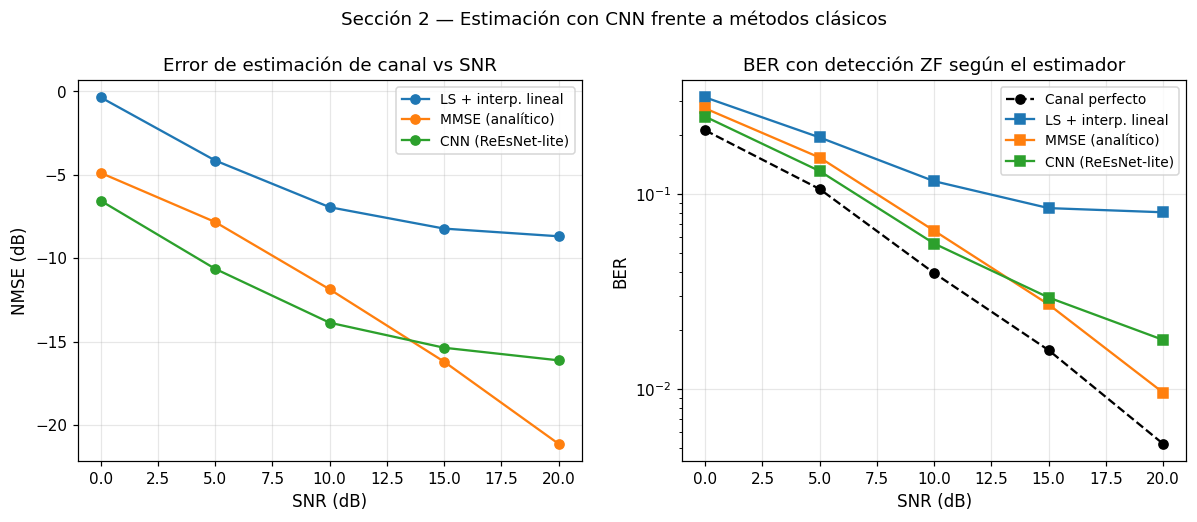

In [13]:
# ---------------- 2.9 NMSE y BER vs SNR con los tres estimadores ----------------
estim2 = {
    "LS + interp. lineal":      partial(est_ls_interp, tipo="linear"),
    "MMSE (analítico)":         partial(est_mmse, pdp=PDP1),
    "CNN (ReEsNet-lite)":       est_cnn,
}
snrs2 = [0, 5, 10, 15, 20]
rng_t = np.random.default_rng(99)
nmse_db = {n: [] for n in estim2}
for s in snrs2:
    sim = simular(cfg1, 300, s, rng_t)
    for n, est in estim2.items():
        Hh = est(cfg1, sim, s)
        nmse_db[n].append(10 * np.log10(np.sum(np.abs(Hh - sim["H"]) ** 2) / np.sum(np.abs(sim["H"]) ** 2)))

ber2 = curva_ber(cfg1, snrs2, {"Canal perfecto": est_perfecto, **estim2}, n_frames=300, seed=5)

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
for n, v in nmse_db.items():
    ejes[0].plot(snrs2, v, "-o", label=n)
ejes[0].set_xlabel("SNR (dB)"); ejes[0].set_ylabel("NMSE (dB)"); ejes[0].set_title("Error de estimación de canal vs SNR"); ejes[0].legend()
for n, v in ber2.items():
    ejes[1].semilogy(snrs2, np.maximum(v, 1e-6), "k--o" if n == "Canal perfecto" else "-s", label=n)
ejes[1].set_xlabel("SNR (dB)"); ejes[1].set_ylabel("BER"); ejes[1].set_title("BER con detección ZF según el estimador"); ejes[1].legend()
fig.suptitle("Sección 2 — Estimación con CNN frente a métodos clásicos", y=1.02)
plt.show()

---
# Sección 3 — Receptores End-to-End y resiliencia de hardware

## 3.1 Receptor DNN *end-to-end*

En lugar de estimar $H$ y luego ecualizar, una DNN recibe **directamente** la señal recibida (dominio de la frecuencia, parte real e imaginaria) y predice los **bits transmitidos**, sin estimar el canal explícitamente:

$$
\hat{\mathbf b} = \mathbb{1}\!\left[\, f_\theta\big(\mathrm{Re}\{\mathbf Y\},\,\mathrm{Im}\{\mathbf Y\}\big) > 0 \right]
$$

Siguiendo la idea de Ye, Li y Juang (2018), la trama tiene **dos símbolos OFDM**: uno piloto (conocido, ocupa todas las subportadoras) y uno de datos. La red ve ambos y debe aprender, de forma implícita, tanto la estimación del canal como la detección. Usamos 5 capas totalmente conectadas y pérdida de entropía cruzada binaria:

$$
\mathcal{L}=-\frac{1}{n}\sum_i \left[b_i\log\sigma(z_i) + (1-b_i)\log(1-\sigma(z_i))\right]
$$

> Para que la red sea entrenable en pocos minutos, esta sección usa un sistema **más pequeño** ($N=16$ subportadoras, 3 trayectos, retardo máximo de 5 muestras, sin Doppler). El detector clásico (LS + ZF) usa el símbolo piloto para estimar $H$ y luego ecualiza el símbolo de datos.

## 3.2 Fallas de hardware

| Escenario | Qué ocurre | Consecuencia |
|---|---|---|
| **Nominal** | CP = 6 ≥ retardo máximo (5) | $Y=HX+N$ exacto |
| **CP insuficiente** | CP = 1 < retardo máximo | ISI entre símbolos e ICI entre subportadoras: ya no se cumple $Y[k]=H[k]X[k]+N[k]$ |
| **Saturación del HPA** | recorte $x\mapsto x\cdot\min(1,A/\lvert x\rvert)$ con $A=1.2\,x_{rms}$ | distorsión no lineal dependiente de los datos |

En los dos últimos casos el modelo lineal $Y=HX+N$ en el que se basan LS y ZF **deja de ser válido**, mientras que la DNN, si se entrena con datos del sistema real (con la falla incluida), puede aprender a compensar parcialmente lo que el modelo clásico ignora.

> **Qué esperar (con cautela).** En el escenario nominal el detector clásico suele ser difícil de superar con una DNN pequeña y poco entrenada. La ventaja de la DNN, cuando aparece, se da sobre todo bajo las fallas, y depende del tamaño de la red, del tiempo de entrenamiento y del rango de SNR. Los resultados que obtengas son parte del experimento: repórtalos aunque no favorezcan a la DNN.

In [14]:
# ---------------- 3.3 Sistema pequeño para el receptor end-to-end ----------------
cfg3 = Cfg(N=16, cp=6, n_sym=2, mod="QPSK", n_taps=3, max_delay=5, tau=3.0, fd=0.0)
cfg3.pilot_mask = np.zeros((cfg3.n_sym, cfg3.N), dtype=bool)
cfg3.pilot_mask[0, :] = True                      # símbolo 0: piloto en TODAS las subportadoras; símbolo 1: datos
N_ENTRADA = 2 * cfg3.n_sym * cfg3.N               # Re/Im de los 2 símbolos recibidos -> 64 entradas
N_SALIDA  = cfg3.n_data * cfg3.bps                # bits del símbolo de datos -> 32 salidas
print(f"Entradas de la DNN: {N_ENTRADA} | Bits a predecir por trama: {N_SALIDA}")

# ---------------- Detector clásico para esta trama: LS con el símbolo piloto + ZF ----------------
def est_ls_zf(cfg, sim, snr_db):
    """H_LS[k] = Y_piloto[k] / X_piloto[k] en todas las subportadoras; se asume canal constante en la trama."""
    Hls = sim["Y"][:, 0, :] / cfg.pilot_vals[0, :]                     # [B, N]
    return np.repeat(Hls[:, None, :], cfg.n_sym, axis=1)               # [B, T, N] (ZF se aplica luego en ber_detector)

# ---------------- Red DNN de 5 capas totalmente conectadas ----------------
class RxDNN(nn.Module):
    def __init__(self, n_in, n_out, ocultas=(256, 256, 128, 64)):
        super().__init__()
        capas, d = [], n_in
        for h in ocultas:                                              # 4 capas ocultas Linear + ReLU
            capas += [nn.Linear(d, h), nn.ReLU()]; d = h
        capas.append(nn.Linear(d, n_out))                              # 5ª capa: logits de cada bit (sin activación)
        self.red = nn.Sequential(*capas)
    def forward(self, x):
        return self.red(x)

print(RxDNN(N_ENTRADA, N_SALIDA))

Entradas de la DNN: 64 | Bits a predecir por trama: 32
RxDNN(
  (red): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
  )
)


In [15]:
# ---------------- 3.4 Generador de datos y entrenamiento del receptor DNN ----------------
def entrada_dnn(sim):
    """Vector de entrada: [Re(Y), Im(Y)] de los dos símbolos OFDM recibidos, aplanado -> [B, 64]."""
    B = sim["Y"].shape[0]
    Y = sim["Y"].reshape(B, -1)
    return np.concatenate([Y.real, Y.imag], axis=1)

def batch_e2e(B, rng, snr_rango, cp, clip):
    snr = rng.uniform(*snr_rango, size=B)
    sim = simular(cfg3, B, snr, rng, cp=cp, clip_ratio=clip)           # la falla de hardware está INCLUIDA en los datos
    x = torch.tensor(entrada_dnn(sim), dtype=torch.float32, device=device)
    y = torch.tensor(sim["bits"].reshape(B, -1), dtype=torch.float32, device=device)   # bits objetivo [B, 32]
    return x, y

def entrenar_e2e(nombre, cp, clip, pasos=5000, B=256, lr=1e-3, snr_rango=(0.0, 30.0), seed=0):
    rng = np.random.default_rng(seed); torch.manual_seed(seed)
    modelo = RxDNN(N_ENTRADA, N_SALIDA).to(device)
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=pasos)
    perdida = nn.BCEWithLogitsLoss()                                   # entropía cruzada binaria sobre los logits
    hist = []
    barra = tqdm(range(pasos), desc=f"Entrenando DNN [{nombre}]", leave=False)
    modelo.train()
    for p in barra:
        x, y = batch_e2e(B, rng, snr_rango, cp, clip)                  # datos nuevos en cada paso
        loss = perdida(modelo(x), y)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        hist.append(loss.item())
        if p % 100 == 0: barra.set_postfix(loss=f"{loss.item():.3f}")
    return modelo.eval(), hist

@torch.no_grad()
def ber_dnn(modelo, sim):
    x = torch.tensor(entrada_dnn(sim), dtype=torch.float32, device=device)
    bits_hat = (modelo(x) > 0).cpu().numpy().astype(int)               # logit > 0  <=>  probabilidad > 0.5
    return np.mean(bits_hat != sim["bits"].reshape(len(bits_hat), -1))

In [16]:
# ---------------- 3.5 Experimento: 3 escenarios, un detector clásico y una DNN por escenario ----------------
PASOS_E2E = 5000          # baja a ~2000 para una versión rápida; sube a 10000+ para mejores resultados
escenarios = {
    "Nominal (CP = 6)":            dict(cp=6, clip=None),
    "CP insuficiente (CP = 1)":    dict(cp=1, clip=None),
    "Clipping del HPA (1.2·RMS)":  dict(cp=6, clip=1.2),
}
snrs3 = np.arange(0, 31, 5)
N_FRAMES_EVAL = 4000
resultados = {}

for nombre, p in escenarios.items():
    modelo, hist = entrenar_e2e(nombre, p["cp"], p["clip"], pasos=PASOS_E2E)
    rng_ev = np.random.default_rng(2024)                               # mismas tramas de evaluación para ambos detectores
    b_cl, b_nn = [], []
    for s in snrs3:
        sim = simular(cfg3, N_FRAMES_EVAL, s, rng_ev, cp=p["cp"], clip_ratio=p["clip"])
        b_cl.append(ber_detector(cfg3, sim, est_ls_zf(cfg3, sim, s)))  # detector clásico LS + ZF
        b_nn.append(ber_dnn(modelo, sim))                              # detector DNN end-to-end
    resultados[nombre] = dict(clasico=np.array(b_cl), dnn=np.array(b_nn), hist=hist, modelo=modelo, p=p)
    print(f"{nombre:28s} | pérdida final DNN: {np.mean(hist[-200:]):.3f}")

Entrenando DNN [Nominal (CP = 6)]:   0%|          | 0/5000 [00:00<?, ?it/s]

Nominal (CP = 6)             | pérdida final DNN: 0.188


Entrenando DNN [CP insuficiente (CP = 1)]:   0%|          | 0/5000 [00:00<?, ?it/s]

CP insuficiente (CP = 1)     | pérdida final DNN: 0.227


Entrenando DNN [Clipping del HPA (1.2·RMS)]:   0%|          | 0/5000 [00:00<?, ?it/s]

Clipping del HPA (1.2·RMS)   | pérdida final DNN: 0.229


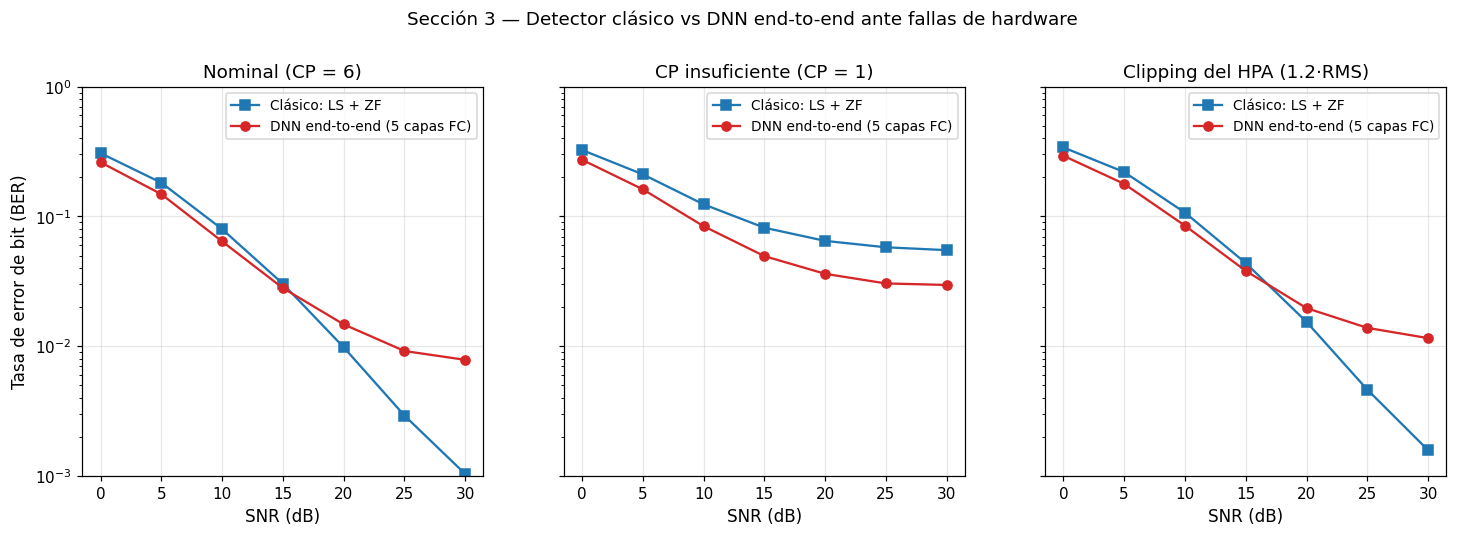

Escenario                       BER clásico    BER DNN   (SNR = 20 dB)
Nominal (CP = 6)                     0.0098     0.0148
CP insuficiente (CP = 1)             0.0648     0.0362
Clipping del HPA (1.2·RMS)           0.0154     0.0197


In [17]:
# ---------------- 3.6 Comparación de BER: Detector clásico (LS + ZF) vs DNN end-to-end ----------------
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
for ax, (nombre, r) in zip(ejes, resultados.items()):
    ax.semilogy(snrs3, np.maximum(r["clasico"], 1e-5), "C0-s", label="Clásico: LS + ZF")
    ax.semilogy(snrs3, np.maximum(r["dnn"], 1e-5),     "C3-o", label="DNN end-to-end (5 capas FC)")
    ax.set_title(nombre); ax.set_xlabel("SNR (dB)"); ax.legend(); ax.set_ylim(1e-3, 1)
ejes[0].set_ylabel("Tasa de error de bit (BER)")
fig.suptitle("Sección 3 — Detector clásico vs DNN end-to-end ante fallas de hardware", y=1.03)
plt.show()

# Tabla resumen a SNR = 20 dB
i20 = list(snrs3).index(20)
print(f"{'Escenario':30s} {'BER clásico':>12s} {'BER DNN':>10s}   (SNR = 20 dB)")
for nombre, r in resultados.items():
    print(f"{nombre:30s} {r['clasico'][i20]:12.4f} {r['dnn'][i20]:10.4f}")

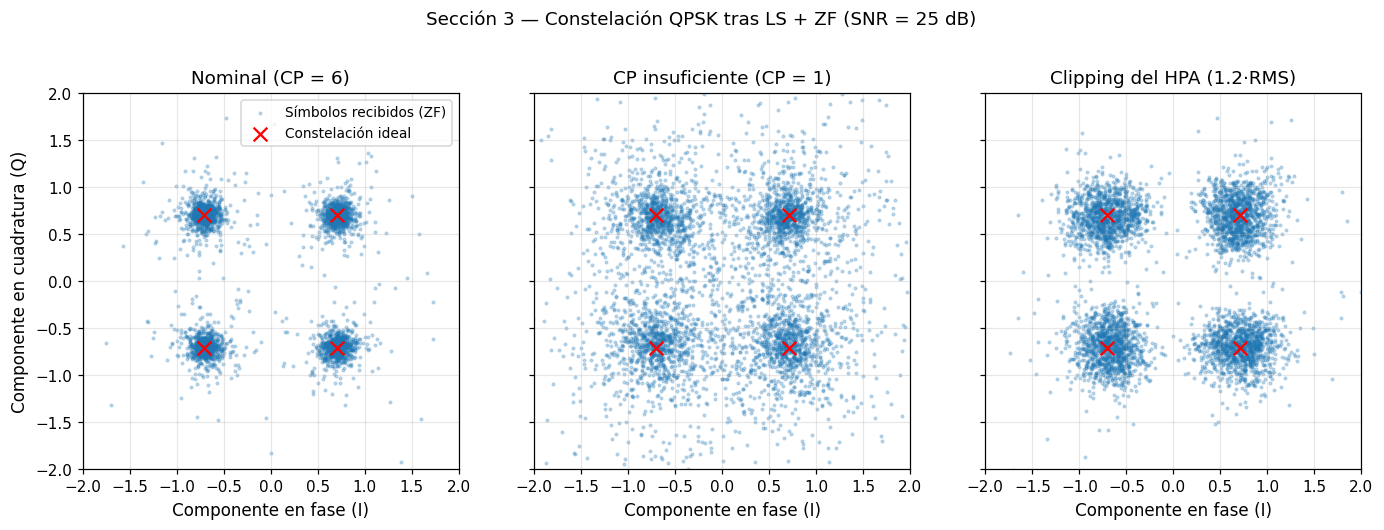

In [18]:
# ---------------- 3.7 Constelaciones tras ecualización ZF: ¿qué le hace la falla a la señal? ----------------
SNR_C = 25.0
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
for ax, (nombre, r) in zip(ejes, resultados.items()):
    sim = simular(cfg3, 300, SNR_C, np.random.default_rng(3), cp=r["p"]["cp"], clip_ratio=r["p"]["clip"])
    Xh = (sim["Y"] / est_ls_zf(cfg3, sim, SNR_C))[:, ~cfg3.pilot_mask].ravel()   # símbolos de datos ecualizados con ZF
    ax.scatter(Xh.real, Xh.imag, s=3, alpha=0.25, label="Símbolos recibidos (ZF)")
    ref = mapear(np.array([[0, 0], [0, 1], [1, 0], [1, 1]]), "QPSK")
    ax.scatter(ref.real, ref.imag, c="r", marker="x", s=80, label="Constelación ideal")
    ax.set_title(nombre); ax.set_xlabel("Componente en fase (I)"); ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_aspect("equal")
ejes[0].set_ylabel("Componente en cuadratura (Q)"); ejes[0].legend(loc="upper right")
fig.suptitle(f"Sección 3 — Constelación QPSK tras LS + ZF (SNR = {SNR_C:.0f} dB)", y=1.03)
plt.show()

---
# Conclusiones y preguntas para el informe

1. **Sección 1.** ¿Por qué el MMSE supera con tanta ventaja a LS + interpolación? Observa también que el spline cúbico puede resultar *peor* que la interpolación lineal: ¿por qué (ruido en los pilotos, extrapolación en las subportadoras 61–63)? Relaciona tu respuesta con la dispersión de retardos, el espaciado de pilotos ($\Delta_p=4$) y la información estadística (PDP) que explota el MMSE.
2. **Sección 2.** Compara el NMSE de la CNN con el del MMSE a SNR bajas y altas. ¿Qué información *a priori* usa el MMSE que la CNN debe aprender de los datos? ¿Qué ocurriría si entrenaras solo con SNR = 20 dB y evaluaras a 0 dB?
3. **Sección 3.** ¿Bajo qué escenario(s) mejora la DNN al detector clásico? Explica por qué LS + ZF depende de $Y=HX+N$ y qué supuesto se rompe con CP corto o con el recorte.
4. **Costo y generalización.** La DNN se entrenó para un canal y una falla concretos. ¿Qué pasaría si en operación el canal tuviera una estadística distinta (otro retardo máximo, Doppler alto)? ¿Cómo se lo diría a un ingeniero de sistemas que valora la robustez?

## Extensiones sugeridas

* Cambia `MODULACION = "16QAM"` (Sección 1) y observa cómo se desplazan las curvas de BER.
* Varía `clip_ratio` (0.8, 1.0, 1.5, 2.0) y `cp` (0, 1, 3, 6) en la Sección 3 y grafica el BER a 20 dB en función del parámetro.
* Aumenta `PASOS_E2E` y observa si la DNN reduce el piso de error a SNR alta.
* En la Sección 2, prueba una CNN más profunda o entrena con pilotos cada 8 subportadoras (¿se cumple aún el muestreo de Nyquist en frecuencia?).

## Referencias

* H. Ye, G. Y. Li, B.-H. Juang, "Power of Deep Learning for Channel Estimation and Signal Detection in OFDM Systems", *IEEE Wireless Communications Letters*, 2018.
* M. Soltani et al., "Deep Learning-Based Channel Estimation" (ChannelNet), 2019.
* L. Li et al., "ReEsNet: Deep Residual Learning for Channel Estimation in OFDM", 2019.